In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X, y = mnist["data"], mnist["target"]
print("X.shape:",X.shape)
print("y.shape:",y.shape)

X.shape: (70000, 784)
y.shape: (70000,)


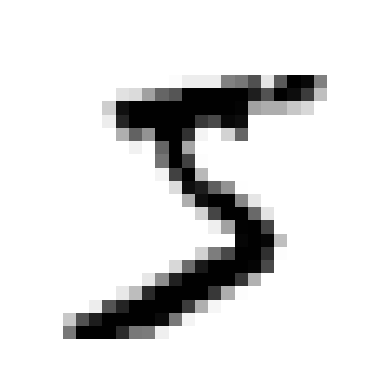

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)

plt.imshow(some_digit_image,cmap='binary')
plt.axis('off')
plt.show()

In [5]:
import numpy as np
y = y.astype(np.uint8)

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


# TREINANDO UM CLASSIFICADOR BINÁRIO

In [7]:
#Queremos identificar quem é 5 e quem não é 5
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)


In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [9]:
#aqui verifica se a imagem é um caractere '5'

sgd_clf.predict([some_digit])

array([ True])

## CÁLCULO DE DESEMPENHO

calculando a acurácia com a validação cruzada

In [10]:
#implementando a validação cruzada

#Vez ou outra você precisará ter mais controle sobre o processo de validação cruzada do que a padronização
#da Sckit-Learn. Nesse caso , você mesmo pode implementar a validação cruzada. 
# O código a seguir faz a mesma coisa que o cross_val_Score() do Sckit Learn

from sklearn.model_selection import StratifiedKFold 
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3,random_state=42,shuffle=True)

for train_index , test_index in skfolds.split(X_train,y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds,y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)

    print(n_correct/len(y_pred))

0.9669
0.91625
0.96785


In [11]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [12]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self,X,Y=None):
        pass
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

In [13]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.91125, 0.90855, 0.90915])

## Matriz de confusão

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5,cv=3)

In [15]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [19]:
y_train_perfect_predictions = y_train_5 # vamos fingir que alcançamos a perfeição

confusion_matrix(y_train_5,y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## Precisão e revocação

# 📊 Métricas de Avaliação de Modelos de Classificação

## 1. Acurácia (Accuracy)
\[
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
\]
👉 Mede o percentual total de acertos.

---

## 2. Precisão (Precision)
\[
\text{Precision} = \frac{TP}{TP + FP}
\]
👉 Quando o modelo diz “é positivo”, quão frequentemente ele acerta.

---

## 3. Recall (Sensibilidade)
\[
\text{Recall} = \frac{TP}{TP + FN}
\]
👉 De todos os positivos verdadeiros, quantos o modelo detecta.


In [23]:
from sklearn.metrics import precision_score, recall_score

#precision
precision_score(y_train_5,y_train_pred)

0.8370879772350012

In [22]:
#recall
recall_score(y_train_5,y_train_pred)

0.6511713705958311

In [ ]:
#f1 score
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_train_5,y_train_pred))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



: 